<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">CNN training</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">אימון CNN על וקטורי EfficientNet-B0</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">כעת נאמן רשת CNN המקבלת וקטור EfficientNet-B0 באורך 1,280 כקלט. המבנה נבחר כרשת קטנה יחסית, כדי לבדוק אם שילובים מקומיים ולא־ליניאריים בין מאפייני הווקטור משפרים את הסיווג בלי ליצור מודל כבד מדי.</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">בהמשך בשלב ניתוח התוצאות נציג למה בחרנו לכלול את                                                 אימון הרשת למרות שהמודל הבסיסי שבו השתמשנו הציג תוצאות                                                                                                   מושלמות על סט הבדיקה.</div>
</div>
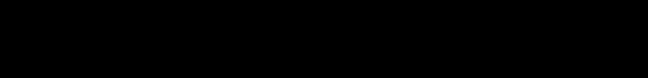
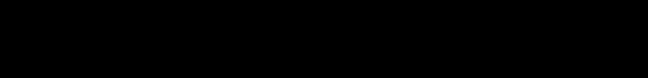

In [1]:
from pathlib import Path
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = Path('passport_full_image_output')
EMBEDDINGS_FILE = OUTPUT_DIR / 'full_page_embeddings.npz'
METADATA_FILE = OUTPUT_DIR / 'full_page_embedding_metadata.csv'
LABELS_FILE = Path('passport_page_labels_big_dataset.csv')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
embeddings = np.load(EMBEDDINGS_FILE)
X = embeddings['X'].astype(np.float32)
metadata_df = pd.read_csv(METADATA_FILE, encoding='utf-8-sig')
labels_df = pd.read_csv(LABELS_FILE, encoding='utf-8-sig')

model_df = metadata_df[['image_name', 'image_path', 'vector_row']].merge(
    labels_df,
    on='image_path',
    how='inner',
    validate='one_to_one',
)

vector_rows = model_df['vector_row'].astype(int).to_numpy()
X_model = X[vector_rows]
y = model_df['label'].astype(int).to_numpy()


print('Saved embedding matrix:', X.shape)
print('Labeled vector matrix:', X_model.shape)
print('Labels:', y.shape)
print(pd.Series(y).value_counts().sort_index().rename(index={0: 'No passport', 1: 'Passport'}))

Saved embedding matrix: (839, 1280)
Labeled vector matrix: (839, 1280)
Labels: (839,)
No passport    595
Passport       244
Name: count, dtype: int64


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">חלוקה לסטים של אימון, ולידציה וטסט</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"> החלוקה היא 70% לאימון, 15% לולידציה ו־15% לטסט. האינדקסים נשמרים כדי שיהיה אפשר לקשר בהמשך את התחזיות בחזרה לשמות התמונות ולנתיבים המקוריים.</div>
</div>

In [3]:
indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=SEED, stratify=y
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=y[temp_idx]
)

X_train, y_train = X_model[train_idx], y[train_idx]
X_val, y_val = X_model[val_idx], y[val_idx]
X_test, y_test = X_model[test_idx], y[test_idx]

print('Train:', X_train.shape, np.bincount(y_train))
print('Validation:', X_val.shape, np.bincount(y_val))
print('Test:', X_test.shape, np.bincount(y_test))

Train: (587, 1280) [416 171]
Validation: (126, 1280) [89 37]
Test: (126, 1280) [90 36]


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">נרמול הווקטורים והתאמת המבנה ל־CNN</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"> מאפייני ה־Embedding יכולים להיות בטווחים ובהתפלגויות שונים. ללא נרמול, מאפיינים בעלי ערכים גדולים עלולים להשפיע יותר על עדכון המשקלים ולגרום לאימון פחות יציב. בנוסף, שכבת <code>Conv1D</code> מצפה לקלט תלת־ממדי ולא למטריצה דו־ממדית רגילה.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מושגים מרכזיים:</b> <code>StandardScaler</code> מחשב לכל מאפיין ממוצע וסטיית תקן על קבוצת האימון בלבד, ולאחר מכן מחסיר את הממוצע ומחלק בסטיית התקן. אותו Scaler מוחל ללא התאמה מחדש על האימות והבדיקה כדי למנוע זליגת מידע. לאחר מכן מתווסף ציר ערוץ, והמבנה משתנה מ־<code>(samples, 1280)</code> ל־<code>(samples, 1280, 1)</code>: מספר דוגמאות, אורך הרצף ומספר ערוצים.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;"><b>מגבלות ושיקולים:</b> בניגוד לפיקסלים או לדגימות זמן, סדר 1,280 מאפייני EfficientNet אינו מבטיח שמאפיינים סמוכים קשורים זה לזה. לכן ההנחה המקומית של קונבולוציה חד־ממדית עשויה להיות חלשה. חשוב להשוות את התוצאה למסווג ליניארי או ל־MLP. בזמן חיזוי עתידי חובה להשתמש באותו Scaler שאומן כאן ובאותו סדר מאפיינים; התאמת Scaler חדש תשנה את הקלט שהמודל מקבל.</div>
</div>

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def prepare_for_cnn(vectors):
    # [samples, 1280] -> [samples, 1280, 1]
    return vectors[..., np.newaxis].astype('float32')

X_train_cnn = prepare_for_cnn(X_train)
X_val_cnn = prepare_for_cnn(X_val)
X_test_cnn = prepare_for_cnn(X_test)

print('CNN input shape:', X_train_cnn.shape)

CNN input shape: (587, 1280, 1)


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">בניית רשת CNN חד־ממדית</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מדוע הקטע נחוץ:</b> לאחר שהווקטורים הותאמו למבנה תלת־ממדי יש להגדיר מודל שילמד שילובים של מאפיינים המבדילים בין דף עם דרכון לדף ללא דרכון. המודל מחזיר הסתברות אחת לכל דוגמה ולכן מתאים לסיווג בינארי.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מבנה הרשת:</b> שכבות <code>Conv1D</code> מפעילות מסננים נלמדים על חלונות של 5 ולאחר מכן 3 מאפיינים. <code>padding='same'</code> שומר על אורך הרצף לפני ה־Pooling, ופונקציית <code>ReLU</code> מוסיפה אי־ליניאריות. <code>MaxPooling1D</code> מקטין את האורך, ו־<code>GlobalMaxPooling1D</code> שומר את התגובה החזקה ביותר מכל מסנן. שכבות <code>Dropout</code> מכבות באקראי חלק מהיחידות בזמן האימון כדי לצמצם התאמת יתר. שכבת הפלט משתמשת ב־<code>sigmoid</code> ומחזירה ערך בין 0 ל־1.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;"><b>מגבלות ושיקולים:</b> מספר המסננים, גודל החלון, שיעור ה־Dropout וגודל השכבה הצפופה הם Hyperparameters ולא ערכים מיטביים מוכחים. Pooling מפחית חישוב אך גם עלול לאבד מידע. המודל מורכב יותר מרגרסיה לוגיסטית ולכן בדאטה קטן הוא עלול לבצע התאמת יתר. פונקציית ההפסד <code>binary_crossentropy</code> מתאימה רק כאשר התוויות הן 0 ו־1.</div>
</div>

In [5]:
model = Sequential([
    Input(shape=(1280, 1)),
    Conv1D(64, kernel_size=5, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, padding='same', activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1280, 64)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 640, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 640, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,649 (29.88 KB)

 Trainable params: 7,649 (29.88 KB)

 Non-trainable params: 0 (0.00 B)

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">אימון המודל וטיפול בחוסר איזון</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מדוע הקטע נחוץ:</b> בשלב זה הרשת מעדכנת את משקליה על סמך דוגמאות האימון. מאחר שבמאגר יכולים להיות יותר דפים ללא דרכון מאשר דפים עם דרכון, מחושב משקל לכל מחלקה כדי שטעות במחלקה הנדירה לא תיבלע בתוך המחלקה הגדולה.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מושגים מרכזיים:</b> <code>class_weight='balanced'</code> נותן משקל גבוה יותר למחלקה שמופיעה פחות באימון. כל Epoch הוא מעבר מלא על קבוצת האימון, ו־<code>batch_size=32</code> קובע כמה דוגמאות מעובדות לפני עדכון משקלים. <code>EarlyStopping</code> עוקב אחרי <code>val_loss</code>, עוצר לאחר חמישה Epochs ללא שיפור ומחזיר את המשקלים מהנקודה הטובה ביותר באמצעות <code>restore_best_weights=True</code>.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;"><b>מגבלות ושיקולים:</b> משקלי מחלקות משנים את מחיר הטעויות ועשויים לשפר Recall של דרכונים במחיר של יותר False Positives. עצירה מוקדמת תלויה באיכות ובגודל קבוצת האימות; קבוצה קטנה עלולה לגרום לתנודות ולעצירה מוקדמת מדי. מספר Epochs וגודל Batch דורשים התאמה לפי כמות הנתונים, זמן הריצה והזיכרון הזמין.</div>
</div>

In [6]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.4344 - auc: 0.5816 - loss: 0.7170 - precision: 0.3002 - recall: 0.7076 - val_accuracy: 0.6508 - val_auc: 0.6950 - val_loss: 0.7118 - val_precision: 0.4462 - val_recall: 0.7838
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5247 - auc: 0.6972 - loss: 0.6706 - precision: 0.3594 - recall: 0.8070 - val_accuracy: 0.6905 - val_auc: 0.7475 - val_loss: 0.7340 - val_precision: 0.4848 - val_recall: 0.8649
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.5877 - auc: 0.7120 - loss: 0.6557 - precision: 0.3953 - recall: 0.7836 - val_accuracy: 0.6587 - val_auc: 0.7299 - val_loss: 0.6952 - val_precision: 0.4118 - val_recall: 0.3784
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6712 - auc: 0.7567 - loss: 0.6367 - precision: 0.4610 - recall: 0.7602 - val_accuracy: 0.7063 - val_auc: 0.7653 - val_loss: 0.7020 - val_precision: 0.5000 - val_recall: 0.5946
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">מעקב אחר עקומות האימון</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מדוע הקטע נחוץ:</b> ציון סופי יחיד אינו מסביר כיצד המודל למד. הצגת Loss ו־Accuracy בכל Epoch מאפשרת לזהות אם האימון עדיין משתפר, אם נעצר מוקדם מדי או אם נוצר פער בין האימון לאימות.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>פירוש העקומות:</b> Loss מודד את גודל השגיאה שעל פיה מתעדכנים המשקלים, ולכן ערך נמוך יותר עדיף. Accuracy הוא שיעור התחזיות הנכונות. ירידה ב־Loss של האימון במקביל לעלייה ב־Loss של האימות היא סימן אופייני להתאמת יתר. ערכים גבוהים או תקועים בשתי הקבוצות עשויים להצביע על תת־התאמה או על הגדרות אימון לא מתאימות.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;"><b>מגבלות ושיקולים:</b> Accuracy עלול להטעות כאשר המחלקות אינן מאוזנות, ולכן אין להסיק מהגרף לבדו שהמודל טוב. יש לבדוק גם Precision, Recall, F1 ו־ROC-AUC. תנודות בעקומת האימות אינן בהכרח כשל, במיוחד כאשר קבוצת האימות קטנה.</div>
</div>

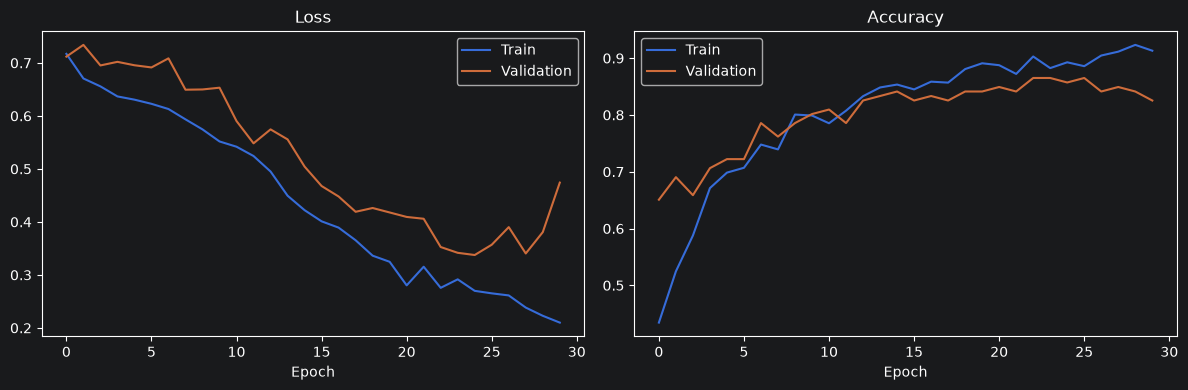

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">הערכת ביצועים על קבוצת הבדיקה</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מדוע הקטע נחוץ:</b> קבוצת הבדיקה מדמה נתונים שהמודל לא ראה בזמן האימון או בבחירת נקודת העצירה. ההערכה עליה מספקת אומדן אמין יותר ליכולת ההכללה ומאפשרת להבין אילו סוגי טעויות המודל מבצע.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מושגים מרכזיים:</b> המודל מחזיר הסתברות לדרכון, וסף 0.5 ממיר אותה לתווית 0 או 1. Precision מודד כמה מהדפים שסווגו כדרכון הם באמת דרכונים; Recall מודד כמה מהדרכונים האמיתיים נמצאו; F1 מאזן בין שניהם. ROC-AUC בוחן את איכות דירוג ההסתברויות לאורך כל הספים. מטריצת הבלבול מציגה True Positives, True Negatives, False Positives ו־False Negatives. בנוסף נשמר CSV עם הנתיב, התווית, התחזית וההסתברות של כל דוגמת בדיקה.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;"><b>מגבלות ושיקולים:</b> סף 0.5 אינו בהכרח מתאים לצורך העסקי; אם חשוב במיוחד לא לפספס דרכונים, יש לבחור סף על קבוצת האימות שמעדיף Recall. אסור לכוון את הסף לפי קבוצת הבדיקה, משום שאז היא מפסיקה להיות הערכה בלתי תלויה. מומלץ לבדוק את קבוצת הבדיקה פעם אחת בלבד ולדווח גם את מספר הדוגמאות בכל מחלקה.</div>
</div>

              precision    recall  f1-score   support

 No passport     1.0000    0.9000    0.9474        90
    Passport     0.8000    1.0000    0.8889        36

    accuracy                         0.9286       126
   macro avg     0.9000    0.9500    0.9181       126
weighted avg     0.9429    0.9286    0.9307       126

ROC-AUC: 0.9793


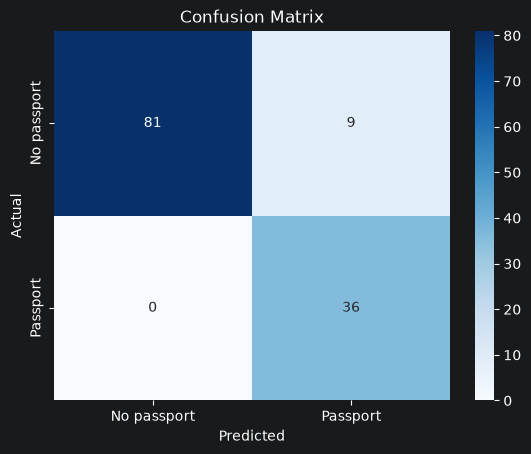

In [8]:
test_probability = model.predict(X_test_cnn, verbose=0).ravel()
test_prediction = (test_probability >= 0.5).astype('int32')

print(classification_report(
    y_test,
    test_prediction,
    target_names=['No passport', 'Passport'],
    digits=4,
    zero_division=0,
))
print('ROC-AUC:', round(roc_auc_score(y_test, test_probability), 4))

cm = confusion_matrix(y_test, test_prediction)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No passport', 'Passport'],
    yticklabels=['No passport', 'Passport'],
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

predictions_df = model_df.iloc[test_idx][
    ['image_name', 'image_path', 'label']
].copy()
predictions_df['prediction'] = test_prediction
predictions_df['passport_probability'] = test_probability
predictions_df.to_csv(
    OUTPUT_DIR / 'full_page_cnn_test_predictions.csv',
    index=False,
    encoding='utf-8-sig',
)

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">שמירת המודל ותוצרי העיבוד</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מדוע הקטע נחוץ:</b> אימון מחדש בכל פעם הוא איטי ועלול להפיק תוצאה שונה. שמירת המודל מאפשרת לטעון את המשקלים והארכיטקטורה לצורך חיזוי על מסמכים חדשים, ושמירת ה־Scaler מבטיחה שהווקטורים החדשים יעברו בדיוק את אותו נרמול שבוצע בזמן האימון.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>תוצרי השלב:</b> <code>full_page_cnn.keras</code> מכיל את מודל Keras, <code>full_page_cnn_scaler.joblib</code> מכיל את פרמטרי הנרמול, ו־<code>full_page_cnn_test_predictions.csv</code> מכיל את תחזיות קבוצת הבדיקה לצורך ניתוח שגיאות. כל הקבצים נשמרים תחת <code>passport_full_image_output</code> לצד הווקטורים והמטא־דאטה.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;"><b>מגבלות ושיקולים:</b> בזמן חיזוי חייבים לשמור על אותו רצף: חילוץ וקטור באמצעות אותה גרסת EfficientNet-B0, שימוש באותו Scaler, הוספת ממד הערוץ ואז הפעלת המודל. שינוי סדר המאפיינים או שימוש ב־Scaler אחר יפגע בתחזיות. מומלץ לשמור גם את גרסאות הספריות, סף ההחלטה ומיפוי התוויות כחלק מניהול גרסאות מלא של המודל.</div>
</div>

In [9]:
model.save(OUTPUT_DIR / 'full_page_cnn.keras')
joblib.dump(scaler, OUTPUT_DIR / 'full_page_cnn_scaler.joblib')

print('Saved model:', OUTPUT_DIR / 'full_page_cnn.keras')
print('Saved scaler:', OUTPUT_DIR / 'full_page_cnn_scaler.joblib')
print('Saved predictions:', OUTPUT_DIR / 'full_page_cnn_test_predictions.csv')

Saved model: passport_full_image_output\full_page_cnn.keras
Saved scaler: passport_full_image_output\full_page_cnn_scaler.joblib
Saved predictions: passport_full_image_output\full_page_cnn_test_predictions.csv


In [18]:
from pathlib import Path

import joblib
import numpy as np

import tensorflow as tf
import torch
import torch.nn as nn

from PIL import Image
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0


# Paths and device
OUTPUT_DIR = Path("passport_full_image_output")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOGISTIC_MODEL_FILE = OUTPUT_DIR / "full_page_logistic_baseline.joblib"
CNN_MODEL_FILE = OUTPUT_DIR / "full_page_cnn.keras"
CNN_SCALER_FILE = OUTPUT_DIR / "full_page_cnn_scaler.joblib"


# Load the two classifiers
logistic_model = joblib.load(LOGISTIC_MODEL_FILE)
cnn_model = tf.keras.models.load_model(CNN_MODEL_FILE)
cnn_scaler = joblib.load(CNN_SCALER_FILE)


# Load EfficientNet-B0 feature extractor
weights = EfficientNet_B0_Weights.DEFAULT
preprocess = weights.transforms()

encoder = efficientnet_b0(weights=weights)
encoder.classifier = nn.Identity()
encoder = encoder.to(DEVICE).eval()


def image_to_vector(image_path):
    """Convert one image to a 1,280-feature EfficientNet-B0 vector."""

    image = Image.open(image_path).convert("RGB")

    # Add white padding without changing the aspect ratio
    side = max(image.size)
    square = Image.new("RGB", (side, side), (255, 255, 255))

    x = (side - image.width) // 2
    y = (side - image.height) // 2
    square.paste(image, (x, y))

    # Prepare the image for EfficientNet
    image_tensor = preprocess(square).unsqueeze(0).to(DEVICE)

    # Extract the vector
    with torch.inference_mode():
        vector = encoder(image_tensor)

    return vector.cpu().numpy().astype(np.float32)


def predict_image(image_path, threshold=0.5):
    """Run both classifiers on one image."""

    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    # Shape: (1, 1280)
    vector = image_to_vector(image_path)

    # Logistic Regression
    logistic_probability = float(
        logistic_model.predict_proba(vector)[0, 1]
    )
    logistic_prediction = int(logistic_probability >= threshold)

    # CNN: normalization and channel dimension
    cnn_input = cnn_scaler.transform(vector).astype(np.float32)
    cnn_input = cnn_input[..., np.newaxis]  # (1, 1280, 1)

    cnn_probability = float(
        cnn_model.predict(cnn_input, verbose=0)[0, 0]
    )
    cnn_prediction = int(cnn_probability >= threshold)

    return pd.DataFrame({
        "model": ["Logistic Regression", "CNN"],
        "prediction": [
            "Passport" if logistic_prediction == 1 else "No passport",
            "Passport" if cnn_prediction == 1 else "No passport",
        ],
        "passport_probability": [
            logistic_probability,
            cnn_probability,
        ],
    })


# Example
IMAGE_PATH = "dataset_images/PDF_Normal_Doc_9_page_3.jpg"

results = predict_image(IMAGE_PATH)
display(results)

,model,prediction,passport_probability
0,Logistic Regression,No passport,0.000138
1,CNN,No passport,0.075503


In [15]:
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm


LABELS_FILE = Path("passport_vector_output/labels.csv")
IMAGES_DIR = Path("dataset_images")
OUTPUT_FILE = Path("passport_full_image_output/model_predictions.csv")

labels_df = pd.read_csv(LABELS_FILE, encoding="utf-8-sig")

predictions = []

for row in tqdm(
    labels_df.itertuples(index=False),
    total=len(labels_df),
    desc="Predicting images"
):
    relative_path = Path(row.relative_path)

    # Support both relative and absolute paths
    if relative_path.is_absolute():
        image_path = relative_path
    else:
        image_path = IMAGES_DIR / relative_path

    # Run both models
    result = predict_image(image_path).set_index("model")

    logistic_probability = result.loc[
        "Logistic Regression", "passport_probability"
    ]
    cnn_probability = result.loc[
        "CNN", "passport_probability"
    ]

    predictions.append({
        "relative_path": row.relative_path,
        "label": row.label,

        "logistic_prediction": int(
            logistic_probability >= 0.5
        ),
        "logistic_probability": logistic_probability,

        "cnn_prediction": int(
            cnn_probability >= 0.5
        ),
        "cnn_probability": cnn_probability,
    })


predictions_df = pd.DataFrame(predictions)

predictions_df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Saved predictions:", OUTPUT_FILE)
display(predictions_df.head())

Predicting images: 100%|██████████| 141/141 [00:51<00:00,  2.74it/s]

Saved predictions: passport_full_image_output\model_predictions.csv


,relative_path,label,logistic_prediction,logistic_probability,cnn_prediction,cnn_probability
0,PDF_Edge_Case_11_page_1.jpg,1,1,0.999999,1,0.954542
1,PDF_Edge_Case_12_page_1.jpg,0,0,0.000255,0,0.061834
2,PDF_Edge_Case_12_page_2.jpg,0,0,0.000572,0,0.363961
3,PDF_Edge_Case_12_page_3.jpg,1,1,1.000000,1,0.924062
4,PDF_Edge_Case_12_page_4.jpg,0,0,0.000141,0,0.346994


,class,count
0,No passport,110
1,Passport,31
2,Total,141


,model,accuracy,precision,recall,f1,roc_auc,correct_predictions,errors
0,Logistic Regression,0.9787,1.0,0.9032,0.9492,1.0,138,3
1,CNN,1.0000,1.0,1.0000,1.0000,1.0,141,0


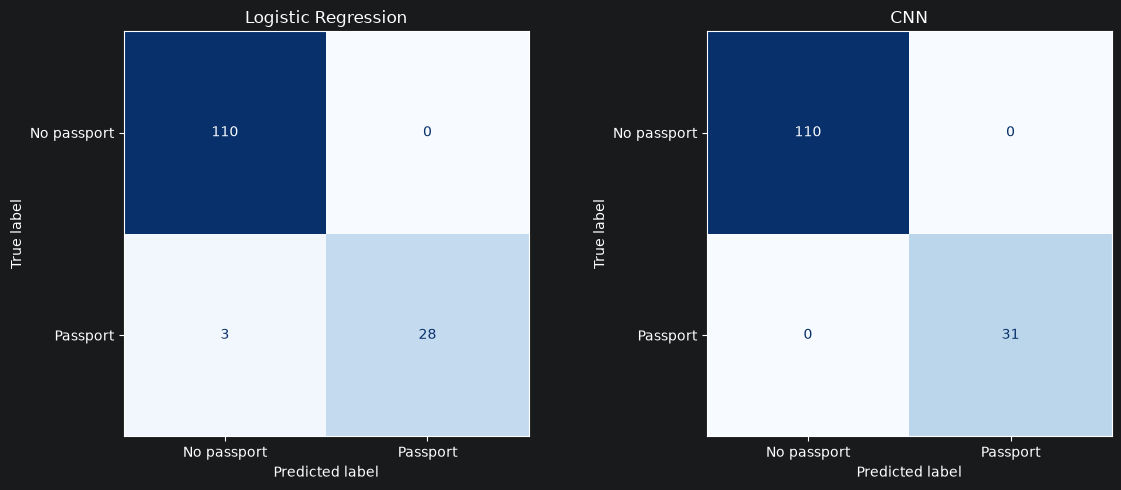

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)


y_true = predictions_df["label"].astype(int)

models = {
    "Logistic Regression": {
        "prediction": "logistic_prediction",
        "probability": "logistic_probability",
    },
    "CNN": {
        "prediction": "cnn_prediction",
        "probability": "cnn_probability",
    },
}


# Dataset statistics
dataset_statistics = pd.DataFrame({
    "class": ["No passport", "Passport", "Total"],
    "count": [
        (y_true == 0).sum(),
        (y_true == 1).sum(),
        len(y_true),
    ],
})

display(dataset_statistics)


# Model statistics
statistics = []

for model_name, columns in models.items():
    y_prediction = predictions_df[
        columns["prediction"]
    ].astype(int)

    y_probability = predictions_df[
        columns["probability"]
    ].astype(float)

    statistics.append({
        "model": model_name,
        "accuracy": accuracy_score(
            y_true, y_prediction
        ),
        "precision": precision_score(
            y_true, y_prediction, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_prediction, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_prediction, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true, y_probability
        ),
        "correct_predictions": (
            y_true == y_prediction
        ).sum(),
        "errors": (
            y_true != y_prediction
        ).sum(),
    })


statistics_df = pd.DataFrame(statistics).round(4)
display(statistics_df)


# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for axis, (model_name, columns) in zip(
    axes, models.items()
):
    y_prediction = predictions_df[
        columns["prediction"]
    ].astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_prediction,
        display_labels=["No passport", "Passport"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )

    axis.set_title(model_name)

plt.tight_layout()
plt.show()

In [ ]:
# Word_Edge_Case_16_page_3.jpg
# Word_Edge_Case_15_page_3.jpg
# Word_Edge_Case_11_page_2.jpg